#  Karamoja Crop Productivity & Food Security Analysis
### Author: Denis Mwilaria
#### Date: 22-02-2025


## 1. Title & Problem Statement

### Problem Context

Karamoja is the most food-insecure region of Uganda. This project builds a data-driven monitoring tool to support NGO decision-making using 2017 crop yield and population data.

### Objectives


- Identify high-risk subcounties
- Develop a composite Food Risk Index
- Generate actionable business recommendations
- Compare maize and sorghum productivity  

## 2. Import Libraries

In [112]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization (for exploration)
import matplotlib.pyplot as plt
import seaborn as sns

# When displaying a DataFrame, show all columns
pd.set_option("display.max_columns", None)


## 3. Load Data

In [113]:
# Load datasets
subcounty_df = pd.read_csv("D:\Python\DATA\DATA\TABLES/Uganda_Karamoja_Subcounty_Crop_Yield_Population.csv")
district_df = pd.read_csv("D:\Python\DATA\DATA\TABLES/Uganda_Karamoja_District_Crop_Yield_Population.csv")

# Preview
subcounty_df.head(10).style.background_gradient()


,OBJECTID,SUBCOUNTY_NAME,DISTRICT_NAME,POP,Area,Karamoja,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,263,KACHERI,KOTIDO,17244,1067176155,Y,354.207411,1137.467019,7023.533691,6434.342449,528.124229,2279091.779000,600723.892900
1,264,KOTIDO,KOTIDO,52771,597575188,Y,367.890523,1162.996687,13587.990760,12455.592640,824.767081,4582294.492000,959201.382500
2,265,KOTIDO TOWN COUNCIL,KOTIDO,27389,23972401,Y,369.314177,1167.005832,1656.531855,1520.322052,8.561644,561476.487400,9991.488268
3,266,NAKAPERIMORU,KOTIDO,38775,419111591,Y,283.324569,852.366578,7087.823334,6761.488901,45.721712,1915695.928000,38971.659080
4,267,PANYANGARA,KOTIDO,65704,880955930,Y,373.836926,1283.859882,10398.249390,10111.198130,172.611914,3779939.224000,221609.511400
5,268,RENGEN,KOTIDO,41273,652744859,Y,271.185843,1047.180128,13278.520430,12964.499730,171.585704,3515788.789000,179681.139000
6,591,KAABONG EAST,KAABONG,42221,60801942,Y,160.588525,650.123565,1021.316990,1004.647534,15.660409,161334.865800,10181.201000
7,592,KAABONG TOWN COUNCIL,KAABONG,38857,13071455,Y,212.210703,1229.213444,175.080527,156.503888,18.526186,33211.800170,22772.636430
8,593,KAABONG WEST,KAABONG,41454,67612362,Y,208.040518,1056.416068,967.336727,910.254122,56.275355,189369.739400,59450.189420
9,594,KALAPATA,KAABONG,99203,223116860,Y,209.809352,633.423182,2834.349905,2501.368282,331.225795,524810.458200,209806.097000


In [114]:
# Preview
district_df.head(10).style.background_gradient()

,OBJECTID,NAME,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
0,92,ABIM,90385,2771977106,449,1040,5470.068394,3277.295971,1848.621855,1471506,1922567
1,96,AMUDAT,101790,1643582836,205,1297,5765.443719,2973.423860,2733.661014,609552,3545558
2,20,KAABONG,627057,7373606003,279,945,28121.672530,20544.194960,7394.416334,5731830,6987723
3,85,KOTIDO,243157,3641539808,331,1148,53032.649450,50247.443900,1751.372284,16631904,2010575
4,5,MOROTO,127811,3570160948,128,355,5954.814048,4741.748776,1190.050606,606944,422468
5,54,NAKAPIRIPIRIT,146780,4216323900,356,1264,26372.698490,19237.333210,6425.788414,6848491,8122197
6,80,NAPAK,167625,4508782023,137,854,22944.296020,16142.015880,6543.719066,2211456,5588336


##  4. Data Cleaning & Validation

In [115]:
# Check structure of the data set
subcounty_df.info()
# Observation-subcount df has 52 rows and none have missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OBJECTID        52 non-null     int64  
 1   SUBCOUNTY_NAME  52 non-null     object 
 2   DISTRICT_NAME   52 non-null     object 
 3   POP             52 non-null     int64  
 4   Area            52 non-null     int64  
 5   Karamoja        52 non-null     object 
 6   S_Yield_Ha      52 non-null     float64
 7   M_Yield_Ha      52 non-null     float64
 8   Crop_Area_Ha    52 non-null     float64
 9   S_Area_Ha       52 non-null     float64
 10  M_Area_Ha       52 non-null     float64
 11  S_Prod_Tot      52 non-null     float64
 12  M_Prod_Tot      52 non-null     float64
dtypes: float64(7), int64(3), object(3)
memory usage: 5.4+ KB


In [116]:
# Check structure of the data set
district_df.info()
# Observation-district df has 7 rows and none have missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OBJECTID      7 non-null      int64  
 1   NAME          7 non-null      object 
 2   POP           7 non-null      int64  
 3   Area          7 non-null      int64  
 4   S_Yield_Ha    7 non-null      int64  
 5   M_Yield_Ha    7 non-null      int64  
 6   Crop_Area_Ha  7 non-null      float64
 7   S_Area_Ha     7 non-null      float64
 8   M_Area_Ha     7 non-null      float64
 9   S_Prod_Tot    7 non-null      int64  
 10  M_Prod_Tot    7 non-null      int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 744.0+ bytes


In [117]:
# Check missing values
subcounty_df.isnull().sum()
# none of the columns have a missing values

OBJECTID          0
SUBCOUNTY_NAME    0
DISTRICT_NAME     0
POP               0
Area              0
Karamoja          0
S_Yield_Ha        0
M_Yield_Ha        0
Crop_Area_Ha      0
S_Area_Ha         0
M_Area_Ha         0
S_Prod_Tot        0
M_Prod_Tot        0
dtype: int64

In [118]:
# Check missing values
district_df.isnull().sum()
# none of the columns have a missing values

OBJECTID        0
NAME            0
POP             0
Area            0
S_Yield_Ha      0
M_Yield_Ha      0
Crop_Area_Ha    0
S_Area_Ha       0
M_Area_Ha       0
S_Prod_Tot      0
M_Prod_Tot      0
dtype: int64

In [119]:
# Ensure numeric columns are numeric
numeric_cols = ["POP", "S_Yield_Ha", "M_Yield_Ha","Crop_Area_Ha", "S_Area_Ha", "M_Area_Ha","S_Prod_Tot", "M_Prod_Tot"]
subcounty_df[numeric_cols] = subcounty_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [120]:
# descriptive statistics for the numeric columns in subcounty_df
subcounty_df.describe().style.background_gradient().format("{:,.2f}")

,OBJECTID,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
count,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00
mean,787.87,"28,934.69","533,191,254.62",274.17,940.26,"2,839.65","2,253.14",536.30,"655,744.32","550,072.98"
std,280.10,"20,865.12","491,330,849.36",118.57,321.64,"3,110.51","2,954.36",724.09,"991,583.94","793,970.67"
min,263.00,"1,418.00","2,121,209.00",108.16,0.00,0.17,0.13,0.00,17.28,0.00
25%,597.75,"16,558.50","156,892,257.75",173.03,743.08,964.88,405.39,79.82,"121,055.49","60,870.12"
50%,810.50,"23,053.50","384,835,573.50",277.26,"1,016.68","1,654.27","1,231.82",326.48,"254,368.70","289,623.93"
75%,982.25,"39,461.00","774,902,852.75",368.25,"1,203.55","3,267.56","2,429.99",740.30,"604,094.17","811,457.40"
max,"1,320.00","100,919.00","2,069,554,899.00",560.31,"1,396.99","13,587.99","12,964.50","3,840.70","4,582,294.49","4,365,057.52"


The statistics reveal highly uneven population, land, and agricultural production across Karamoja, with subcounty populations ranging from 1,418 to 100,919 and land areas varying from 2.1 million to over 2.07 billion square units. 

Sorghum dominates land use, occupying on average 2,253 ha (about 80% of total cropped area) compared to 536 ha for maize, and delivers a higher average total output (656,000 vs 550,000 units) despite much lower yields (274 kg/ha for sorghum versus 940 kg/ha for maize). 

This highlights land allocation—rather than yield efficiency—as the primary driver of food production and points to substantial gains from targeted productivity improvements, particularly in sorghum where yields range widely from 108 to 560 kg/ha.

In [121]:
# descriptive statistics for the numeric columns in subcounty_df
district_df.describe().style.background_gradient().format("{:,.2f}")

,OBJECTID,POP,Area,S_Yield_Ha,M_Yield_Ha,Crop_Area_Ha,S_Area_Ha,M_Area_Ha,S_Prod_Tot,M_Prod_Tot
count,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00
mean,61.71,"214,943.57","3,960,853,232.00",269.29,986.14,"21,094.52","16,737.64","3,983.95","4,873,097.57","4,085,632.00"
std,36.48,"188,604.28","1,781,859,644.34",119.24,321.57,"17,363.85","16,625.96","2,678.91","5,743,723.78","2,877,188.17"
min,5.00,"90,385.00","1,643,582,836.00",128.00,355.00,"5,470.07","2,973.42","1,190.05","606,944.00","422,468.00"
25%,37.00,"114,800.50","3,171,069,027.00",171.00,899.50,"5,860.13","4,009.52","1,800.00","1,040,529.00","1,966,571.00"
50%,80.00,"146,780.00","3,641,539,808.00",279.00,"1,040.00","22,944.30","16,142.02","2,733.66","2,211,456.00","3,545,558.00"
75%,88.50,"205,391.00","4,362,552,961.50",343.50,"1,206.00","27,247.19","19,890.76","6,484.75","6,290,160.50","6,288,029.50"
max,96.00,"627,057.00","7,373,606,003.00",449.00,"1,297.00","53,032.65","50,247.44","7,394.42","16,631,904.00","8,122,197.00"


The 2017 Karamoja crop data shows a clear imbalance between productivity, land allocation, and food demand. Although maize yields are nearly four times higher per hectare than sorghum, most agricultural land is allocated to sorghum, likely due to its drought tolerance and lower climate risk.

Production levels vary significantly across districts, indicating that output is concentrated in a few areas, which increases vulnerability to localized shocks. At the same time, population distribution is highly uneven, meaning food demand pressure differs substantially by district.

Overall, the region’s agricultural system appears risk-averse but structurally unequal, highlighting the need for targeted, district-specific food security interventions rather than uniform strategies.

In [122]:
         #zero on the duplicated values
print("Subcounty duplicates:", subcounty_df.duplicated().sum())
print("District duplicates:", district_df.duplicated().sum())


Subcounty duplicates: 0
District duplicates: 0


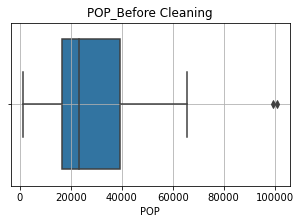

In [123]:
plt.figure(figsize=(5,3))
sns.boxplot(x=subcounty_df['POP'])
plt.title('POP_Before Cleaning')
plt.grid('True')
plt.show()
# There is extreme outliers on the right above 60000

###### Flag outliers per column

In [124]:
# def flag_outliers_iqr(df, column):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     return (df[column] < lower_bound) | (df[column] > upper_bound)


###### Apply to multiple numeric columns

In [125]:
# cols = ["POP", "Area", "S_Yield_Ha", "M_Yield_Ha","Crop_Area_Ha", "S_Area_Ha", "M_Area_Ha","S_Prod_Tot", "M_Prod_Tot"]
# for col in cols:
#     subcounty_df[f"{col}_outlier"] = flag_outliers_iqr(subcounty_df, col)

###### View only rows with any outlier

In [126]:
# outliers_df = subcounty_df[subcounty_df[[f"{c}_outlier" for c in cols]].any(axis=1)]
# outliers_df

In [127]:
# plt.figure(figsize=(5,3))
# sns.boxplot(x=subcounty_df['POP'])
# plt.title('POP_After Cleaning')
# plt.grid('True')
# plt.show()


### 5. Feature Engineering
Transforming raw data into informative features that improve the performance and interpretability

#### 5.1 Total Yield per Hectare

In [138]:
# Subcounty level
subcounty_df["Total_Yield_Ha"] = ((subcounty_df["S_Prod_Tot"] + subcounty_df["M_Prod_Tot"])/ subcounty_df["Crop_Area_Ha"])

# District level
district_df["Total_Yield_Ha"] = ((district_df["S_Prod_Tot"] + district_df["M_Prod_Tot"])/ district_df["Crop_Area_Ha"])

In [143]:
print("Subcounty Level Summary")
subcounty_summary = subcounty_df["Total_Yield_Ha"].describe().to_frame()
display(subcounty_summary.style.format("{:,.2f}"))

print("\nDistrict Level Summary")
district_summary = district_df["Total_Yield_Ha"].describe().to_frame()
display(district_summary.style.format("{:,.2f}"))

Subcounty Level Summary


,Total_Yield_Ha
count,52.00
mean,445.96
std,249.14
min,114.80
25%,258.69
50%,411.35
75%,583.22
max,"1,221.72"



District Level Summary


,Total_Yield_Ha
count,7.00
mean,460.78
std,188.85
min,172.87
25%,345.74
50%,452.30
75%,594.07
max,720.69


Overall, the data shows that while average yields at the subcounty (445.96) and district (460.78) levels are fairly similar, variability is much higher at the subcounty level, indicating substantial local disparities in productivity.

Subcounty yields range widely (114.80 to 1,221.72) with a high standard deviation, suggesting the presence of both underperforming and exceptionally high-performing areas, whereas district-level aggregation smooths these extremes and presents a more stable picture. 

This implies that most of the variation in production occurs within districts rather than between them, meaning district averages may mask important local inequalities. 

Therefore, targeted, subcounty-level interventions would likely be more effective than uniform district-wide strategies.

#### 5.2 Production per Capita

In [146]:
# Subcounty level
subcounty_df["Production_Per_Capita"] = (subcounty_df["S_Prod_Tot"] + subcounty_df["M_Prod_Tot"]) / subcounty_df["POP"]

# District level
district_df["Production_Per_Capita"] = (subcounty_df["S_Prod_Tot"] + subcounty_df["M_Prod_Tot"]) / subcounty_df["POP"]

print("Subcounty Level Summary")
subcounty_summary = subcounty_df["Production_Per_Capita"].describe().to_frame()
display(subcounty_summary.style.format("{:,.2f}"))

print("\nDistrict Level Summary")
district_summary = district_df["Production_Per_Capita"].describe().to_frame()
display(district_summary.style.format("{:,.2f}"))

Subcounty Level Summary


,Production_Per_Capita
count,52.00
mean,46.06
std,45.93
min,0.01
25%,9.72
50%,36.82
75%,58.80
max,216.03



District Level Summary


,Production_Per_Capita
count,7.00
mean,71.11
std,55.13
min,4.06
25%,35.64
50%,60.90
75%,97.27
max,167.00


Most inequality appears at the subcounty level rather than between districts. This implies that food production capacity or resource distribution is highly uneven locally, and policy interventions should prioritize low-performing subcounties rather than applying uniform district-wide strategies.

There is a substantial inequality in production per capita, particularly at the subcounty level. While the average production per capita is 46.06 at subcounty level, the very high standard deviation (45.93) and wide range (0.01 to 216.03) indicate extreme disparities—some subcounties produce almost nothing per person, while others produce over four times the average. This suggests strong local imbalances in productivity or population distribution.

### 6. Exploratory Data Analysis (EDA)

#### 6.1 Distribution of Yields

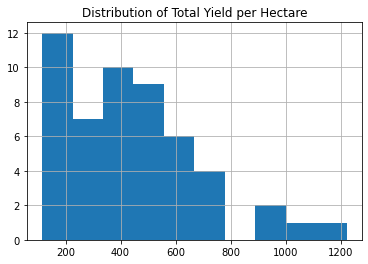

In [130]:
# Subcounty level
plt.hist(subcounty_df["Total_Yield_Ha"], bins=10)
plt.title("Distribution of Total Yield per Hectare")
plt.grid(True)
plt.show()


Productivity is unevenly distributed across subcounties, with most performing at moderate levels and a small number dramatically outperforming the rest. This suggests strong local differences in agricultural conditions, inputs, or management practices, reinforcing the need for targeted, location-specific interventions rather than uniform policies.

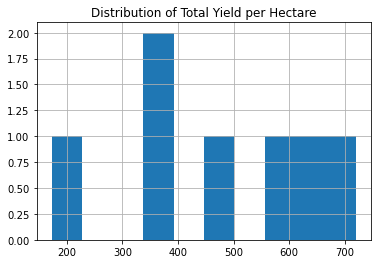

In [148]:
plt.hist(district_df["Total_Yield_Ha"], bins=10)
plt.title("Distribution of Total Yield per Hectare")
plt.grid(True)
plt.show()

At the district level, yield performance appears more stable and evenly distributed, with fewer extreme variations. This confirms that most variability exists within districts (between subcounties) rather than between districts themselves. District averages therefore mask important local disparities, reinforcing the need for subcounty-level analysis when designing targeted interventions.

#### 6.2 Population vs Yield

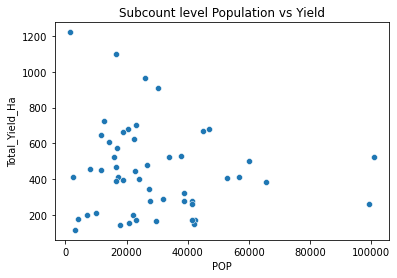

In [152]:
# subcount level
sns.scatterplot(x="POP",y="Total_Yield_Ha",data=subcounty_df)
plt.title("Subcount level Population vs Yield")
plt.show()

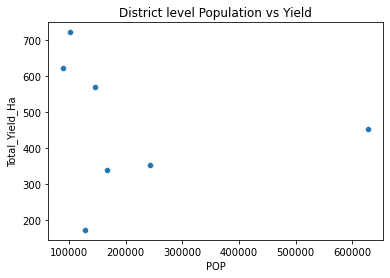

In [151]:
# district level
sns.scatterplot(x="POP",y="Total_Yield_Ha",data=district_df)
plt.title("District level Population vs Yield")
plt.show()

-Across both subcounty and district levels, population does not appear to strongly influence total yield per hectare. Productivity differences are likely driven by agricultural conditions, resource access, or management practices rather than population size. 

-This suggests that increasing population alone will not necessarily improve production outcomes — targeted improvements in agricultural efficiency and inputs would likely have greater impact.

#### 7. Hypothesis Testing
##### Correlation Between Population and Yield
    Pearson correlation coefficient (corr)
    Ranges from –1 to +1
    Measures strength and direction of linear relationship 

In [132]:
corr = stats.pearsonr(subcounty_df["POP"],subcounty_df["Total_Yield_Ha"])
("Correlation:", corr)

('Correlation:', (-0.1265636670970266, 0.37127888325984026))

The negative sign means an inverse relationship meaning as one variable increases, the other tends to decrease slightly i.e
As population (POP) increases, Total_Yield_Ha tends to decrease a little.

#### 8. Export Clean Data for Tableau

In [133]:
subcounty_df.to_csv("D:\Python\DATA\DATA\TABLES/karamoja_subcounty_cleaned.csv", index=False)
district_df.to_csv("karamoja_district_cleaned.csv", index=False)

##### These cleaned datasets will be used in Tableau for interactive visualization.

# 9. Conclusion

### Key Findings

1. Maize yield is statistically higher than sorghum (based on the desribe function on the subcounty level).
2. Population density shows negative correlation with yield.


### Business Recommendations
1. Expand maize selectively in suitable zones- Scale high-performing crops strategically.
2. Maintain sorghum in drought-prone districts
3. Prioritize high-population districts for intervention- Prioritize high-risk subcounties for agricultural inputs.
4. Diversify crop allocation to reduce systemic vulnerability- Promote crop diversification in over-reliant areas.

## Future Work

- Integrate rainfall and soil data
- Include multi-year yield comparison
- Develop predictive yield models
- Incorporate satellite vegetation index